<a href="https://colab.research.google.com/github/ubsuny/PHY386/blob/tenkid-hw3/2026/HW/tenkid/HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/ubsuny/PHY386/blob/main/2026/HW/HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tendo Ssempebwa HW3
I tied my phy to an office chair and spun it around twice while leting it to natural come rest. The only challenge I face with this process was was being able to set up the remote data recoding function for phyphox with I was able to resolve.

## Part 2: Data Analysis with pandas (8 points)



In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Load your data
df = pd.read_csv('https://raw.githubusercontent.com/ubsuny/PHY386/refs/heads/tenkid-hw3/2026/HW/tenkid/tenkid_hw3_data.csv', sep='\t')

# Inspecting the data
display(df.head(10)) # Pint ing the first 10 rows

,Time (s),Gyroscope x (rad/s),Gyroscope y (rad/s),Gyroscope z (rad/s),Absolute (rad/s)
0,0.009664,-0.003816,0.008851,0.004552,0.010660
1,0.019611,-0.002435,0.012851,0.006552,0.014629
2,0.029558,-0.002917,0.003410,0.001738,0.004812
3,0.039505,-0.000784,0.003907,-0.004592,0.006080
4,0.049452,-0.004589,0.014072,0.001107,0.014843
5,0.059399,-0.005232,0.012661,0.001082,0.013742
6,0.069346,-0.005005,0.006568,0.000189,0.008260
7,0.079293,-0.004428,0.008739,0.002071,0.010014
8,0.089239,-0.004547,0.004402,-0.001694,0.006551
9,0.099186,-0.003132,0.001252,-0.001669,0.003764


In [41]:
display(df.describe()) # provides discription of the data

,Time (s),Gyroscope x (rad/s),Gyroscope y (rad/s),Gyroscope z (rad/s),Absolute (rad/s)
count,3128.000000,3128.000000,3128.000000,3128.000000,3128.000000
mean,15.561633,0.217023,0.442546,-4.466447,4.509454
std,8.983235,0.142889,0.266986,2.515919,2.505678
min,0.009664,-0.133011,-0.040414,-7.668312,0.000449
25%,7.785655,0.115865,0.298196,-6.273245,3.587584
50%,15.561637,0.243364,0.521693,-5.706043,5.744828
75%,23.337613,0.324603,0.616867,-3.571098,6.311121
max,31.113586,0.783495,1.388534,0.415505,7.717903


In [42]:
df.isnull().sum() # checks for missing values.

,0
Time (s),0
Gyroscope x (rad/s),0
Gyroscope y (rad/s),0
Gyroscope z (rad/s),0
Absolute (rad/s),0


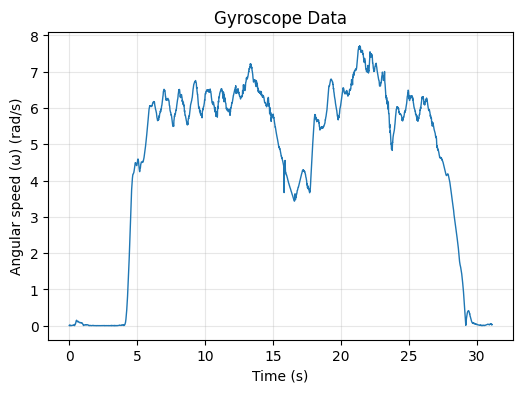

In [46]:
#  Aixs Lables
time = df['Time (s)']
omega = df['Absolute (rad/s)']

# Ploting the data
plt.figure(figsize=(6,4))
plt.plot(time, omega, lw=1)
plt.xlabel('Time (s)')
plt.ylabel('Angular speed (ω) (rad/s)')
plt.title('Gyroscope Data')
plt.grid(True, alpha=0.3)
plt.show()


Trimmed interval: 13.0 s to 18.0 s
Number of fitted points: 503

Summary of trimmed angular speed data:
mean    5.163213
std     1.206094
min     3.432098
max     7.219719
Name: Absolute (rad/s), dtype: float64


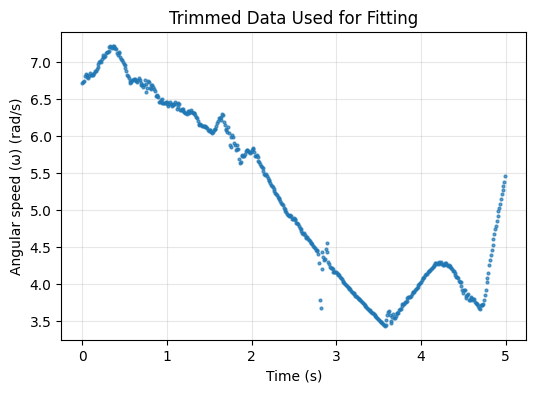

In [49]:

# Range of data to be trimed.
tStart = 13
tEnd = 18

# Triming the data
mask = (time >= tStart) & (time <= tEnd)
time_fit = time[mask] - time[mask].iloc[0]   # reset time so fit starts at t = 0
omega_fit = omega[mask]

# Printing out information about the trimed data
print(f'\nTrimmed interval: {tStart:.1f} s to {tEnd:.1f} s')
print(f'Number of fitted points: {len(time_fit)}')
print('\nSummary of trimmed angular speed data:')
print(pd.Series(omega_fit).describe()[['mean', 'std', 'min', 'max']])

# Ploting trimed data
plt.figure(figsize=(6,4))
plt.plot(time_fit, omega_fit, linestyle='None', marker=".", markersize=4, alpha=0.7)
plt.xlabel('Time (s)')
plt.ylabel('Angular speed (ω) (rad/s)')
plt.title('Trimmed Data Used for Fitting')
plt.grid(True, alpha=0.3)
plt.show()

## Part 3: Model Fitting (8 points)



omega_0 = 7.357 ± 0.050 rad/s
beta    = 0.152 ± 0.003 s^-1


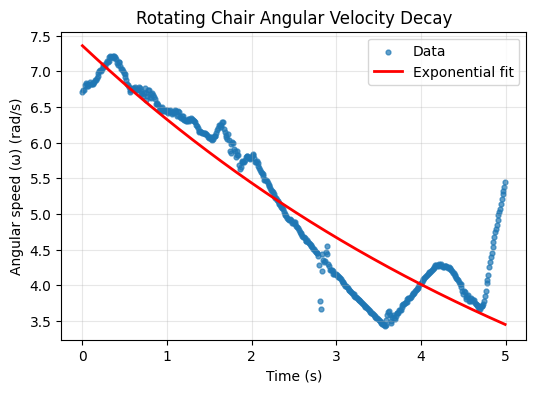

In [50]:
# Example for exponential decay (gyroscope or sound):
def Fit_curve(t, omega0, beta):
    return omega0 * np.exp(-beta * t)

p0 = [omega_fit.iloc[0], 0.2]

popt, pcov = curve_fit(Fit_curve, time_fit, omega_fit, p0=p0, maxfev=10000)
omega0_fit, beta_fit = popt
uncertainties = np.sqrt(np.diag(pcov))

omega_model = Fit_curve(time_fit, *popt)
residuals = omega_fit - omega_model

print(f"omega_0 = {omega0_fit:.3f} ± {uncertainties[0]:.3f} rad/s")
print(f"beta    = {beta_fit:.3f} ± {uncertainties[1]:.3f} s^-1")

plt.figure(figsize=(6, 4))
plt.scatter(time_fit, omega_fit, s=12, alpha=0.7, label='Data')
plt.plot(time_fit, omega_model, 'r-', linewidth=2, label='Exponential fit')
plt.xlabel('Time (s)')
plt.ylabel('Angular speed (ω) (rad/s)')
plt.title('Rotating Chair Angular Velocity Decay')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The fit makes sense, the data for the most part follows the decay equation $\omega_0 * \text{exp}(-\beta * t)$. Because the section of data that I picked for the fit was the one when the chair was naturally solwing down

## Part 4: Advanced Visualization (8 points)



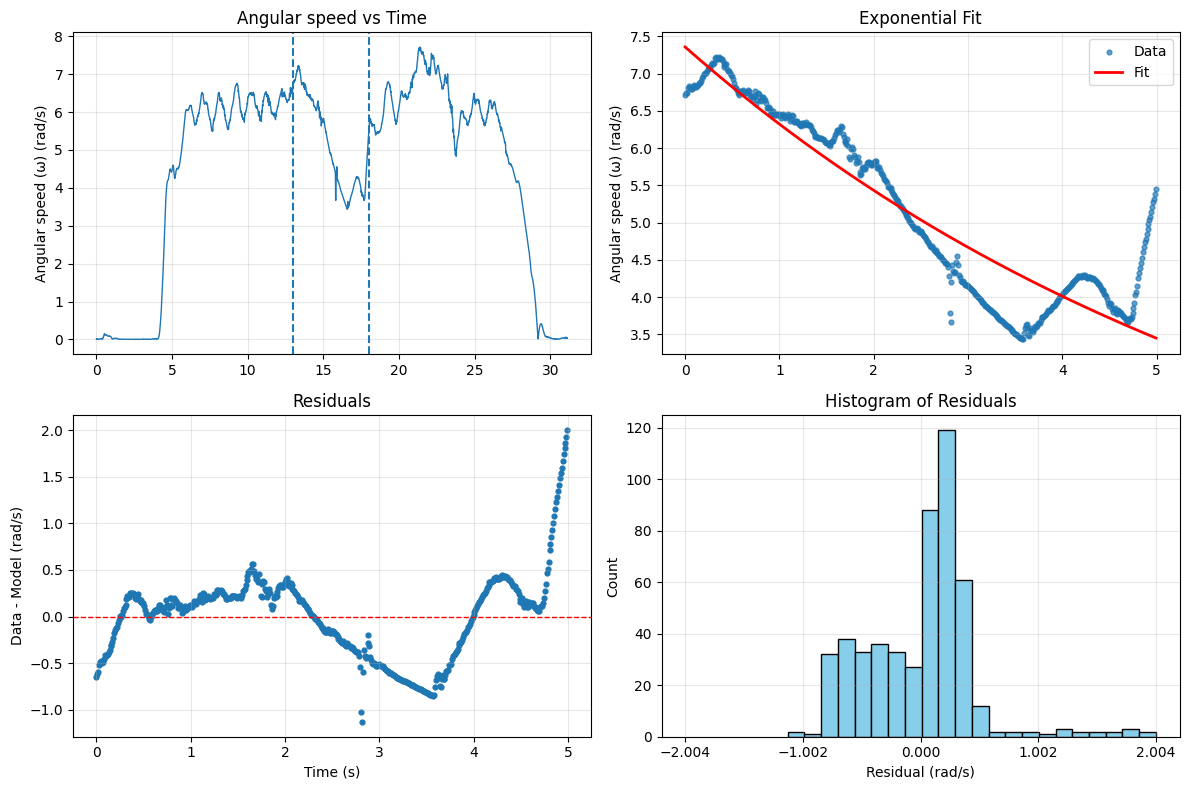

R^2 = 0.8489


In [52]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# Top-left: raw data
ax[0, 0].plot(time, omega, lw=1)
ax[0, 0].axvline(tStart, ls='--')
ax[0, 0].axvline(tEnd, ls='--')
ax[0, 0].set_title('Angular speed vs Time')
ax[0, 0].set_ylabel('Angular speed (ω) (rad/s)')
ax[0, 0].grid(True, alpha=0.3)

# Top-right: trimmed data + fit
ax[0, 1].scatter(time_fit, omega_fit, s=12, alpha=0.7, label='Data')
ax[0, 1].plot(time_fit, omega_model, 'r-', lw=2, label='Fit')
ax[0, 1].set_title('Exponential Fit')
ax[0, 1].set_ylabel('Angular speed (ω) (rad/s)')
ax[0, 1].legend()
ax[0, 1].grid(True, alpha=0.3)

# Bottom-left: residuals
ax[1, 0].scatter(time_fit, residuals, s=12)
ax[1, 0].axhline(0, color='r', ls='--', lw=1)
ax[1, 0].set_title('Residuals')
ax[1, 0].set_xlabel('Time (s)')
ax[1, 0].set_ylabel('Data - Model (rad/s)')
ax[1, 0].grid(True, alpha=0.3)

# Bottom-right: histogram of residuals
ax[1, 1].hist(residuals, bins='auto', edgecolor='black', color='skyblue')
ax[1, 1].set_title('Histogram of Residuals')
ax[1, 1].set_xlabel('Residual (rad/s)')
ax[1, 1].set_ylabel('Count')
ax[1, 1].grid(True, alpha=0.3)

# Adjust x-axis for clarity
max_abs_residual = np.max(np.abs(residuals))
ax[1, 1].set_xlim(-max_abs_residual * 1.1, max_abs_residual * 1.1) # Symmetric limits
ax[1, 1].set_xticks(np.linspace(-max_abs_residual * 1.0, max_abs_residual * 1.0, 5)) # Fewer, evenly spaced ticks

plt.tight_layout()
plt.show()

# A simple goodness-of-fit number
ss_res = np.sum(residuals**2)
ss_tot = np.sum((omega_fit - np.mean(omega_fit))**2)
r_squared = 1 - ss_res/ss_tot
print(f'R^2 = {r_squared:.4f}')

## Part 5: Error Analysis (8 points)



In [53]:
sigma_omega0, sigma_beta = np.sqrt(np.diag(pcov))
print("Fitted parameters with uncertainty:")
print(f"omega_0 = {omega0_fit:.3f} ± {sigma_omega0:.3f} rad/s")
print(f"beta    = {beta_fit:.4f} ± {sigma_beta:.4f} s^-1")

Fitted parameters with uncertainty:
omega_0 = 7.357 ± 0.050 rad/s
beta    = 0.1517 ± 0.0029 s^-1


The sensor has an uncertainty of $\pm$0.01 rad/s, which could highly accurate in my opinion



Error in my experiment could have been caused by the fact that I spun the chair twice at two different intervals.




I am sure my data is correct beacuse there is a potion of it that follows the exponatal fit curve.